# Baseline

Full-order neural-network policy trained on full-order dynamics.

- **Policy**: MLP with two hidden layers of 256 units each (`NET_ARCH = [256, 256]`), mapping the 9-dim observation directly to a single cart-force command. No model structure assumed.
- **Dynamics**: Trained entirely inside the MuJoCo rigid-body simulation — full nonlinear physics. The policy never sees a reduced or linearised model.
- **Observation**: 9 dimensions: `x_cart`, `sin(θ₁)`, `sin(θ₂)`, `cos(θ₁)`, `cos(θ₂)`, `ẋ`, `θ̇₁`, `θ̇₂`, `constraint_force`. Nothing is discarded.


In [15]:
import os
import numpy as np
import matplotlib.pyplot as plt
import gymnasium as gym
from tqdm.auto import tqdm
from stable_baselines3 import PPO
from stable_baselines3.common.callbacks import BaseCallback, EvalCallback, CheckpointCallback
from stable_baselines3.common.env_util import make_vec_env
from stable_baselines3.common.evaluation import evaluate_policy

# ── Config ─────────────────────────────────────────────────────────────────────
ENV_ID          = "InvertedDoublePendulum-v5"
TOTAL_STEPS     = 400_000
N_ENVS          = 8
N_EVAL_ENVS     = 4
N_STEPS         = 2048
BATCH_SIZE      = 64
ENT_COEF        = 0.001
GAMMA           = 0.99
LEARNING_RATE   = 3e-4
NET_ARCH        = [64, 64]
N_EVAL_EPISODES = 20
EVAL_FREQ       = max(1, 25_000 // N_ENVS)
CHECKPOINT_DIR  = "checkpoints/baseline"
MODEL_PATH      = "checkpoints/baseline/ppo_double_pendulum"

_env      = gym.make(ENV_ID)
MAX_STEPS = _env.spec.max_episode_steps   # 1000
DT        = _env.unwrapped.dt             # 0.05 s
_env.close()

os.makedirs(CHECKPOINT_DIR, exist_ok=True)
print(f"MAX_STEPS = {MAX_STEPS}  |  DT = {DT} s  |  max episode = {MAX_STEPS * DT:.1f} s")

MAX_STEPS = 1000  |  DT = 0.05 s  |  max episode = 50.0 s


In [16]:
def plot_results(ep_lengths, ep_rewards, eval_steps, eval_lengths, eval_rewards, total_steps):
    fig, axes = plt.subplots(2, 2, figsize=(13, 8))
    (ax_len, ax_rew), (ax_ep_len, ax_ep_rew) = axes

    # Training curve — episode length
    ax_len.axhspan(MAX_STEPS, MAX_STEPS * 1.05, color="green", alpha=0.15, zorder=0,
                   label=f"Task complete  ({MAX_STEPS} steps = {MAX_STEPS*DT:.0f} s)")
    ax_len.plot(eval_steps, eval_lengths, color="steelblue", lw=1.5)
    ax_len.fill_between(eval_steps, eval_lengths, alpha=0.15, color="steelblue")
    ax_len.axhline(MAX_STEPS, color="green", ls="--", lw=1.5)
    breakthrough = eval_steps[eval_lengths >= MAX_STEPS]
    if len(breakthrough):
        ax_len.axvline(breakthrough[0], color="red", ls=":", lw=1,
                       label=f"first solve @ {breakthrough[0]:.2f}M steps")
    ax_len.set_ylim(0, MAX_STEPS * 1.04)
    ax_len.set_xlabel("Training steps (M)"); ax_len.set_ylabel("Mean episode length")
    ax_len.set_title("Learning curve — episode length"); ax_len.legend(fontsize=8)

    # Training curve — reward
    ax_rew.plot(eval_steps, eval_rewards, color="coral", lw=1.5)
    ax_rew.fill_between(eval_steps, eval_rewards, alpha=0.15, color="coral")
    ax_rew.axhline(0, color="gray", ls="--", lw=1, label="reward = 0")
    if len(breakthrough):
        ax_rew.axvline(breakthrough[0], color="red", ls=":", lw=1)
    ax_rew.set_xlabel("Training steps (M)"); ax_rew.set_ylabel("Mean cumulative reward")
    ax_rew.set_title("Learning curve — reward"); ax_rew.legend(fontsize=8)

    # Final eval — per-episode length
    eps = range(1, len(ep_lengths) + 1)
    ax_ep_len.axhspan(MAX_STEPS, MAX_STEPS * 1.05, color="green", alpha=0.15, zorder=0,
                      label=f"Task complete  ({MAX_STEPS} steps)")
    ax_ep_len.bar(eps, ep_lengths, color="steelblue", zorder=2)
    ax_ep_len.axhline(np.mean(ep_lengths), color="red", ls="--", zorder=3,
                      label=f"mean = {np.mean(ep_lengths):.0f}")
    ax_ep_len.axhline(MAX_STEPS, color="green", ls="--", lw=1.5, zorder=3)
    ax_ep_len.set_ylim(0, MAX_STEPS * 1.04)
    ax_ep_len.set_xlabel("Episode"); ax_ep_len.set_ylabel("Steps")
    ax_ep_len.set_title("Final eval — episode length"); ax_ep_len.legend(fontsize=8)

    # Final eval — per-episode reward
    ax_ep_rew.bar(eps, ep_rewards, color="coral", zorder=2)
    ax_ep_rew.axhline(np.mean(ep_rewards), color="red", ls="--", zorder=3,
                      label=f"mean = {np.mean(ep_rewards):.1f}")
    ax_ep_rew.axhline(0, color="gray", ls=":", alpha=0.7, zorder=3)
    ax_ep_rew.set_xlabel("Episode"); ax_ep_rew.set_ylabel("Cumulative reward")
    ax_ep_rew.set_title("Final eval — episode reward"); ax_ep_rew.legend(fontsize=8)

    plt.suptitle(
        f"PPO double pendulum balance — {total_steps/1e6:.1f}M steps  |  "
        f"max episode = {MAX_STEPS} steps ({MAX_STEPS*DT:.0f} s)",
        fontsize=10,
    )
    plt.tight_layout()
    plt.show()

---

## Training

PPO runs in `N_ENVS` parallel environments. `EvalCallback` periodically evaluates the policy and saves the best checkpoint. No behavioural cloning or reward curriculum needed — `InvertedDoublePendulum-v5` has a dense, well-shaped reward from the start.

In [17]:
class _TqdmCallback(BaseCallback):
    """tqdm progress bar + in-memory training history (no table output)."""

    def __init__(self, total_steps: int):
        super().__init__(verbose=0)
        self._pbar = tqdm(total=total_steps, unit="step", desc="PPO")
        self.history: dict = {"timesteps": [], "ep_len": [], "ep_rew": []}

    def _on_step(self) -> bool:
        return True

    def _on_rollout_end(self) -> None:
        self._pbar.n = self.num_timesteps
        if self.model.ep_info_buffer:
            ep_len = np.mean([ep["l"] for ep in self.model.ep_info_buffer])
            ep_rew = np.mean([ep["r"] for ep in self.model.ep_info_buffer])
            self._pbar.set_postfix(ep_len=f"{ep_len:.0f}", ep_rew=f"{ep_rew:.1f}", refresh=False)
            self.history["timesteps"].append(self.num_timesteps)
            self.history["ep_len"].append(float(ep_len))
            self.history["ep_rew"].append(float(ep_rew))
        self._pbar.refresh()

    def _on_training_end(self) -> None:
        self._pbar.n = self._pbar.total
        self._pbar.refresh()
        self._pbar.close()


vec_env = make_vec_env(ENV_ID, n_envs=N_ENVS)

eval_env = make_vec_env(ENV_ID, n_envs=N_EVAL_ENVS)
eval_cb = EvalCallback(
    eval_env,
    best_model_save_path=CHECKPOINT_DIR,
    log_path=CHECKPOINT_DIR,
    eval_freq=EVAL_FREQ,
    n_eval_episodes=N_EVAL_EPISODES,
    deterministic=True,
    verbose=0,
)

checkpoint_cb = CheckpointCallback(
    save_freq=max(1, 200_000 // N_ENVS),
    save_path=CHECKPOINT_DIR,
    name_prefix="ckpt",
    verbose=0,
)

tqdm_cb = _TqdmCallback(TOTAL_STEPS)

model = PPO(
    "MlpPolicy",
    vec_env,
    n_steps=N_STEPS,
    batch_size=BATCH_SIZE,
    ent_coef=ENT_COEF,
    gamma=GAMMA,
    learning_rate=LEARNING_RATE,
    policy_kwargs=dict(net_arch=NET_ARCH),
    verbose=0,
)

model.learn(total_timesteps=TOTAL_STEPS, callback=[eval_cb, checkpoint_cb, tqdm_cb])
model.save(MODEL_PATH)
vec_env.close()
eval_env.close()
print(f"Done — final ep_len {tqdm_cb.history['ep_len'][-1]:.0f} / {MAX_STEPS}")

PPO:   0%|          | 0/400000 [00:00<?, ?step/s]

Done — final ep_len 794 / 1000


Evaluating: checkpoints/baseline/best_model.zip
Mean length : 1000.0 / 1000 steps (50.0 s)
Mean reward : 9335.02 +/- 1.08
Survival >50%: 100%
Perfect (=1000): 100%


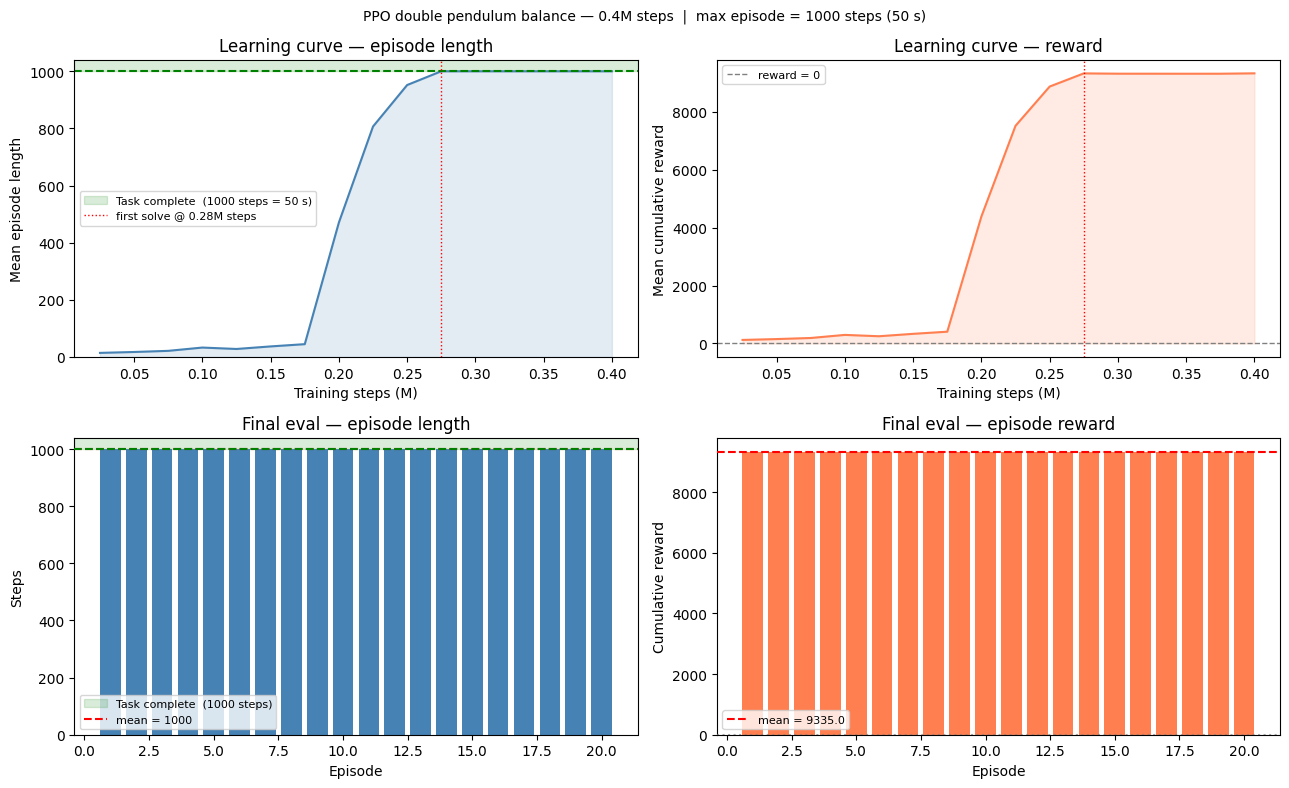

In [18]:
best       = os.path.join(CHECKPOINT_DIR, "best_model.zip")
model_path = best if os.path.exists(best) else MODEL_PATH + ".zip"

eval_env = make_vec_env(ENV_ID, n_envs=N_EVAL_ENVS)
model    = PPO.load(model_path, env=eval_env)
print(f"Evaluating: {model_path}")

ep_rewards, ep_lengths = evaluate_policy(
    model, eval_env,
    n_eval_episodes=N_EVAL_EPISODES,
    return_episode_rewards=True,
    deterministic=True,
)
eval_env.close()

print(f"Mean length : {np.mean(ep_lengths):.1f} / {MAX_STEPS} steps ({np.mean(ep_lengths)*DT:.1f} s)")
print(f"Mean reward : {np.mean(ep_rewards):.2f} +/- {np.std(ep_rewards):.2f}")
print(f"Survival >50%: {100*np.mean(np.array(ep_lengths)>MAX_STEPS//2):.0f}%")
print(f"Perfect (={MAX_STEPS}): {100*np.mean(np.array(ep_lengths)==MAX_STEPS):.0f}%")

evals = np.load(os.path.join(CHECKPOINT_DIR, "evaluations.npz"))
plot_results(
    ep_lengths, ep_rewards,
    evals["timesteps"] / 1e6,
    evals["ep_lengths"].mean(axis=1),
    evals["results"].mean(axis=1),
    TOTAL_STEPS,
)

**Observationns**

---

## Policy Network Architecture

In [19]:
from torchinfo import summary

print(f"Observation dim : 9")
print(f"  x_cart  sin(θ₁)  sin(θ₂)  cos(θ₁)  cos(θ₂)  ẋ  θ̇₁  θ̇₂  constraint_force")
print(f"Action dim      : 1   (cart force ∈ [−1, 1])")
print(f"Net arch        : {NET_ARCH}  (shared trunk → separate actor / critic heads)\n")

summary(
    model.policy,
    input_size=(1, 9),
    col_names=["input_size", "output_size", "num_params", "trainable"],
    col_width=18,
    depth=4,
    verbose=1,
)

Observation dim : 9
  x_cart  sin(θ₁)  sin(θ₂)  cos(θ₁)  cos(θ₂)  ẋ  θ̇₁  θ̇₂  constraint_force
Action dim      : 1   (cart force ∈ [−1, 1])
Net arch        : [64, 64]  (shared trunk → separate actor / critic heads)

Layer (type:depth-idx)                   Input Shape        Output Shape       Param #            Trainable
ActorCriticPolicy                        [1, 9]             [1, 1]             1                  True
├─FlattenExtractor: 1-1                  [1, 9]             [1, 9]             --                 --
│    └─Flatten: 2-1                      [1, 9]             [1, 9]             --                 --
├─MlpExtractor: 1-2                      [1, 9]             [1, 64]            --                 True
│    └─Sequential: 2-2                   [1, 9]             [1, 64]            --                 True
│    │    └─Linear: 3-1                  [1, 9]             [1, 64]            640                True
│    │    └─Tanh: 3-2                    [1, 64]            [

Layer (type:depth-idx)                   Input Shape        Output Shape       Param #            Trainable
ActorCriticPolicy                        [1, 9]             [1, 1]             1                  True
├─FlattenExtractor: 1-1                  [1, 9]             [1, 9]             --                 --
│    └─Flatten: 2-1                      [1, 9]             [1, 9]             --                 --
├─MlpExtractor: 1-2                      [1, 9]             [1, 64]            --                 True
│    └─Sequential: 2-2                   [1, 9]             [1, 64]            --                 True
│    │    └─Linear: 3-1                  [1, 9]             [1, 64]            640                True
│    │    └─Tanh: 3-2                    [1, 64]            [1, 64]            --                 --
│    │    └─Linear: 3-3                  [1, 64]            [1, 64]            4,160              True
│    │    └─Tanh: 3-4                    [1, 64]            [1, 64]       

---

## Policy Rollout — State Trajectories

Roll out one deterministic episode with the trained policy and record the full state trajectory. Plots confirm the policy simultaneously controls cart position and keeps both poles upright across the entire 50-second window.

Episode  : 1000 / 1000 steps  (50.0 s)  ← TASK COMPLETE
Mean r   : 9.3349   cumulative: 9334.93
Cart pos : max |x| = 0.4744 m  (limit 0.2 m)


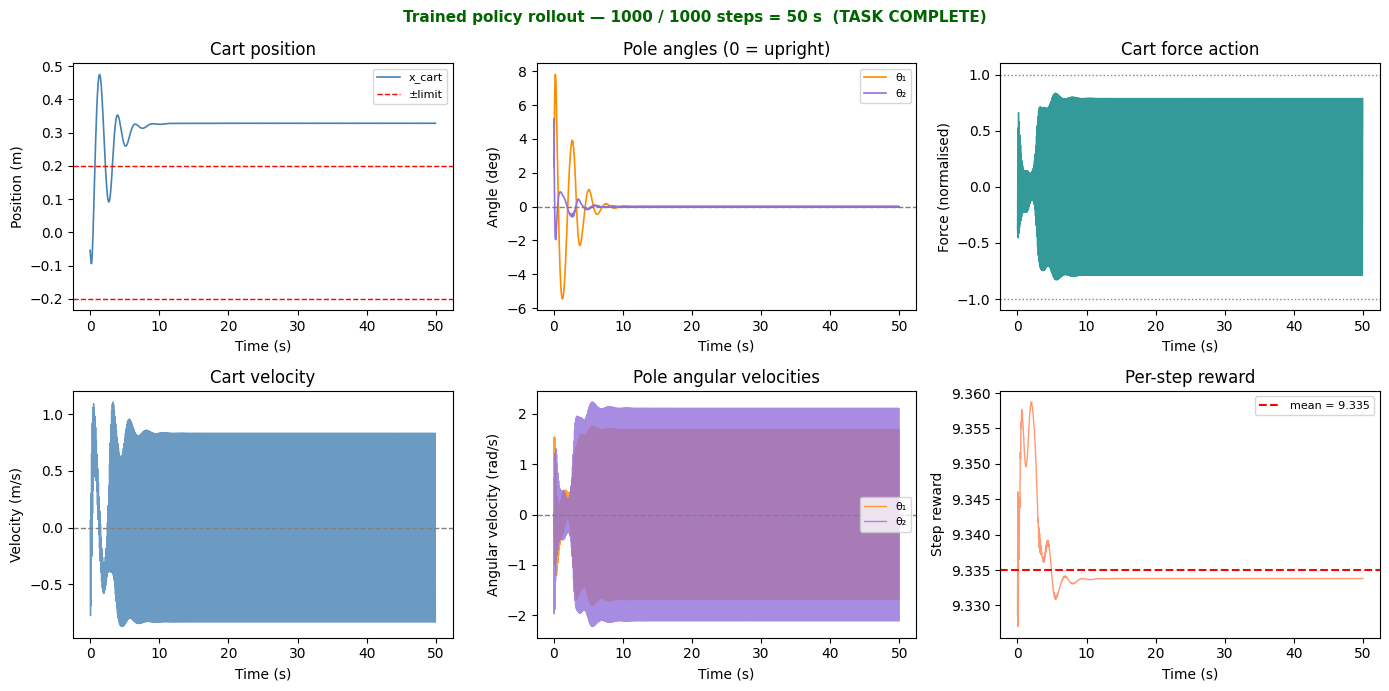

In [20]:
best       = os.path.join(CHECKPOINT_DIR, "best_model.zip")
model_path = best if os.path.exists(best) else MODEL_PATH + ".zip"

rollout_env = gym.make(ENV_ID)
model       = PPO.load(model_path)
obs, _      = rollout_env.reset()

# 9-dim obs: [x, sin(θ₁), sin(θ₂), cos(θ₁), cos(θ₂), ẋ, θ̇₁, θ̇₂, constraint_force]
x_arr    = []
sin_th1  = []; sin_th2  = []
xdot_arr = []; th1dot_arr = []; th2dot_arr = []
rew_arr  = []; act_arr  = []

done = truncated = False
while not (done or truncated):
    x_arr.append(float(obs[0]))
    sin_th1.append(float(obs[1]));  sin_th2.append(float(obs[2]))
    xdot_arr.append(float(obs[5])); th1dot_arr.append(float(obs[6])); th2dot_arr.append(float(obs[7]))
    action, _ = model.predict(obs, deterministic=True)
    obs, r, done, truncated, _ = rollout_env.step(action)
    rew_arr.append(float(r))
    act_arr.append(float(action[0]))
rollout_env.close()

n_steps = len(act_arr)
time    = np.arange(n_steps) * DT
status  = "TASK COMPLETE" if n_steps >= MAX_STEPS else "FAILED"
print(f"Episode  : {n_steps} / {MAX_STEPS} steps  ({n_steps*DT:.1f} s)  ← {status}")
print(f"Mean r   : {np.mean(rew_arr):.4f}   cumulative: {sum(rew_arr):.2f}")
print(f"Cart pos : max |x| = {max(abs(v) for v in x_arr):.4f} m  (limit 0.2 m)")

# ── Plot ──────────────────────────────────────────────────────────────────────
fig, axes = plt.subplots(2, 3, figsize=(14, 7))
(ax_x, ax_th, ax_act), (ax_xd, ax_thd, ax_rew) = axes

ax_x.plot(time, x_arr, color="steelblue", lw=1.2, label="x_cart")
ax_x.axhline( 0.20, color="red", ls="--", lw=1, label="±limit")
ax_x.axhline(-0.20, color="red", ls="--", lw=1)
ax_x.set_xlabel("Time (s)"); ax_x.set_ylabel("Position (m)")
ax_x.set_title("Cart position"); ax_x.legend(fontsize=8)

ax_th.plot(time, np.degrees(np.arcsin(np.clip(sin_th1, -1, 1))), color="darkorange", lw=1.2, label="θ₁")
ax_th.plot(time, np.degrees(np.arcsin(np.clip(sin_th2, -1, 1))), color="mediumpurple", lw=1.2, label="θ₂")
ax_th.axhline(0, color="gray", ls="--", lw=1)
ax_th.set_xlabel("Time (s)"); ax_th.set_ylabel("Angle (deg)")
ax_th.set_title("Pole angles (0 = upright)"); ax_th.legend(fontsize=8)

ax_act.plot(time, act_arr, color="teal", lw=1.0, alpha=0.8)
ax_act.axhline( 1, color="gray", ls=":", lw=1)
ax_act.axhline(-1, color="gray", ls=":", lw=1)
ax_act.set_xlabel("Time (s)"); ax_act.set_ylabel("Force (normalised)")
ax_act.set_title("Cart force action")

ax_xd.plot(time, xdot_arr, color="steelblue", lw=1.0, alpha=0.8)
ax_xd.axhline(0, color="gray", ls="--", lw=1)
ax_xd.set_xlabel("Time (s)"); ax_xd.set_ylabel("Velocity (m/s)")
ax_xd.set_title("Cart velocity")

ax_thd.plot(time, th1dot_arr, color="darkorange", lw=1.0, alpha=0.8, label="θ̇₁")
ax_thd.plot(time, th2dot_arr, color="mediumpurple", lw=1.0, alpha=0.8, label="θ̇₂")
ax_thd.axhline(0, color="gray", ls="--", lw=1)
ax_thd.set_xlabel("Time (s)"); ax_thd.set_ylabel("Angular velocity (rad/s)")
ax_thd.set_title("Pole angular velocities"); ax_thd.legend(fontsize=8)

ax_rew.plot(time, rew_arr, color="coral", lw=1.0, alpha=0.8)
ax_rew.axhline(np.mean(rew_arr), color="red", ls="--", lw=1.5,
               label=f"mean = {np.mean(rew_arr):.3f}")
ax_rew.set_xlabel("Time (s)"); ax_rew.set_ylabel("Step reward")
ax_rew.set_title("Per-step reward"); ax_rew.legend(fontsize=8)

suptitle_color = "darkgreen" if n_steps >= MAX_STEPS else "red"
plt.suptitle(
    f"Trained policy rollout — {n_steps} / {MAX_STEPS} steps = {n_steps*DT:.0f} s  ({status})",
    fontsize=11, fontweight="bold", color=suptitle_color,
)
plt.tight_layout()
plt.show()

---

## Policy Visualisation

One rendered episode captured as an animation (4× speed). Visually confirms both poles remain upright and the cart stays within bounds for the full 50-second window.

In [21]:
import matplotlib.animation as animation
from IPython.display import HTML

best       = os.path.join(CHECKPOINT_DIR, "best_model.zip")
model_path = best if os.path.exists(best) else MODEL_PATH + ".zip"

render_env = gym.make(ENV_ID, render_mode="rgb_array")
model      = PPO.load(model_path)
obs, _     = render_env.reset()

frames = [render_env.render()]
done = truncated = False
while not (done or truncated):
    action, _ = model.predict(obs, deterministic=True)
    obs, _, done, truncated, _ = render_env.step(action)
    frames.append(render_env.render())
render_env.close()

n_steps = len(frames) - 1
status  = "TASK COMPLETE" if n_steps >= MAX_STEPS else "FAILED"
print(f"Episode: {n_steps} / {MAX_STEPS} steps  ({n_steps*DT:.1f} s)  ← {status}")

fig, ax = plt.subplots(figsize=(4, 6))
ax.axis("off")
ax.set_title(
    f"PPO baseline — {n_steps} steps = {n_steps*DT:.0f} s  ({status})",
    fontsize=9, color="darkgreen" if n_steps >= MAX_STEPS else "red",
)
im = ax.imshow(frames[0])

def _update(i):
    im.set_data(frames[i])
    return [im]

ani = animation.FuncAnimation(
    fig, _update,
    frames=range(0, len(frames), 4),
    interval=50, blit=True,
)
plt.close(fig)
HTML(ani.to_jshtml())

Episode: 1000 / 1000 steps  (50.0 s)  ← TASK COMPLETE
